This EDA is focused on the goal of producing a signal autoencoder as a first step to building the complete ECG digitizer which will be a system of models built in a modular way so as to better evaluate and tune each component separately, then later join them together with adapters.

The signal itself sets the minimum size of the autoencoder latent space. This is based on the fact that if the autoencoder cannot reconstruct the signal from the latent space, then it will not be able to reconstruct the signal later from the image encoder.

The notebook follows my thought process as I explore and validate the data. Though, I will say upfront that I polished it up a bit to make it more presentable. Of course, my first pass through was messy and iterative as is the nature of EDA.

In [1]:
import pandas as pd
import os
from PIL import Image
import seaborn as sns
import numpy as np

In [2]:
DATA_DIR = "data"
ECG_DIR = os.path.join(DATA_DIR, "train")
data_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

Start EDA by looking for any missing data.

In [3]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       977 non-null    int64
 1   fs       977 non-null    int64
 2   sig_len  977 non-null    int64
dtypes: int64(3)
memory usage: 23.0 KB


In [4]:
data_df.describe()

,id,fs,sig_len
count,9.770000e+02,977.000000,977.000000
mean,2.143116e+09,590.055271,5900.552712
std,1.296314e+09,315.892515,3158.925149
min,7.663343e+06,250.000000,2500.000000
25%,9.720851e+08,256.000000,2560.000000
50%,2.112147e+09,500.000000,5000.000000
75%,3.316191e+09,1000.000000,10000.000000
max,4.292119e+09,1025.000000,10250.000000


977 sets of ECGs. The datset index says there are no nulls in the data. Though, each one of those sets has a csv with signal data and multiple images of the same ECG. We need to check if there are any missing csv signal files and that they they match the sampling rate and number of samples.

In [5]:
sample_df = pd.read_csv(os.path.join(ECG_DIR, '7663343', f'{7663343}.csv'))
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I       1250 non-null   float64
 1   II      5000 non-null   float64
 2   III     1250 non-null   float64
 3   aVR     1250 non-null   float64
 4   aVL     1250 non-null   float64
 5   aVF     1250 non-null   float64
 6   V1      1250 non-null   float64
 7   V2      1250 non-null   float64
 8   V3      1250 non-null   float64
 9   V4      1250 non-null   float64
 10  V5      1250 non-null   float64
 11  V6      1250 non-null   float64
dtypes: float64(12)
memory usage: 468.9 KB


The range index says it goes up to 5000. However, the only signal that does that is Lead II. So the other leads must have nulls in the time positions where there is no signal data. This follows with the ECG images.

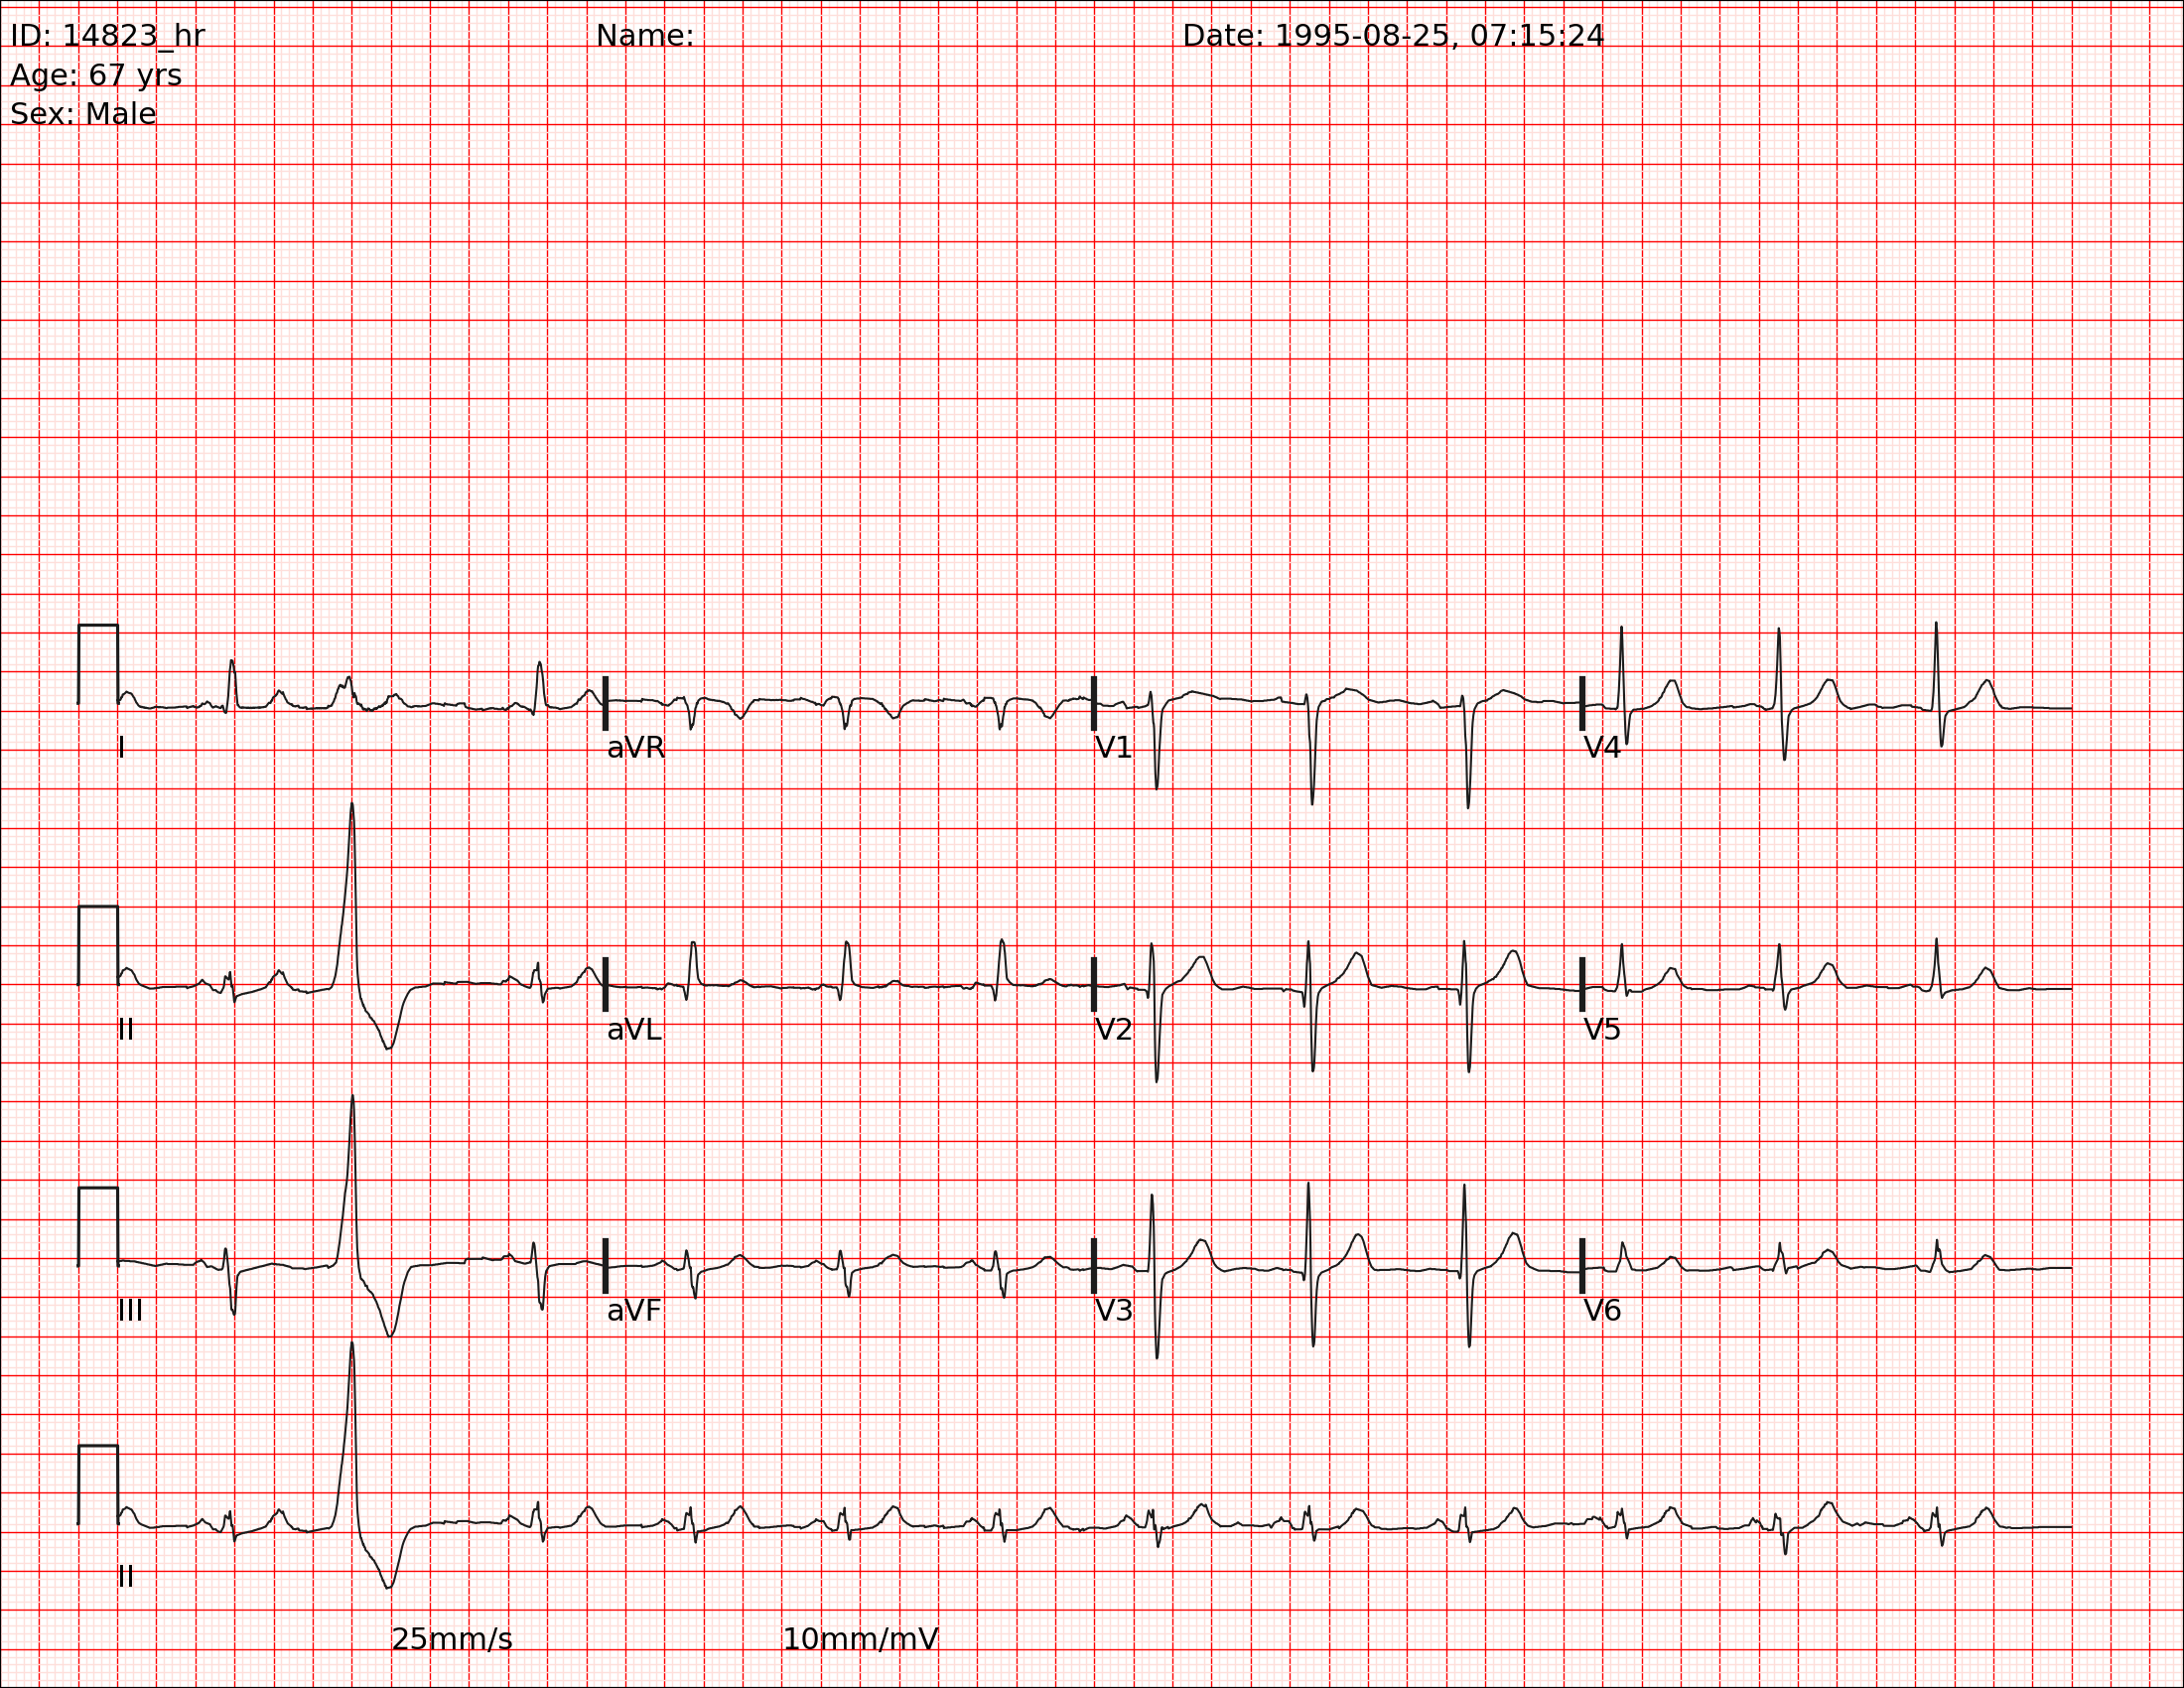

In [6]:
with Image.open(os.path.join(ECG_DIR, '7663343','7663343-0001.png')) as ecg_image:
    display(ecg_image)

Notice Lead II is twice the number of samples as the other leads. Look at the actual ECG and this appears normal due to Lead II displayed twice. Once as 10s/4=2.5s with the other leads and once as the full 10s.

Something else to note about the smaller segements is that ther are shown at different intervals in the 10s window. For example Lead aVF goes from 2.5s to 5s, but the rest of the signal is hidden. The reasoning behind why only portions of the signal are shown is left to a cardiolist to explain and not relevant to the digitizing the signal.

For the purposes of the signal autoencoder, I'll treat the 2.5s segments as separate signals and not consider that they are occuring at different intervals in the 10s window. We do not have data about the other signals for the rest of the 10s period. Therefore cannot train a model to reconstruct the full 10s, other than for Lead II.

The dataset then will actually give me many more than 977 samples for the signal autoencoder. Each of the samples has 11 2.5s signals and 1 10s signal. Using only a 2.5s window for the autoencoder would yield $977 \times 15 = 10747$ samples.

If we inspect one of the signals with nulls we should expect that the nulls occur at the points we cannot see in the ECG.

<Axes: ylabel='V1'>

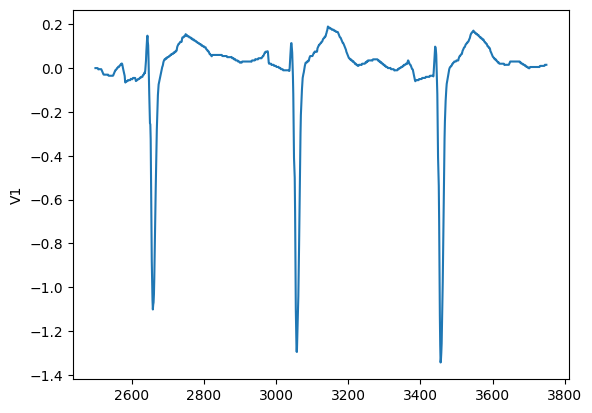

In [7]:
ecg_id = 7663343
signal_csv_path = os.path.join(ECG_DIR, str(ecg_id), f'{ecg_id}.csv')
sample_df = pd.read_csv(signal_csv_path)
sns.lineplot(sample_df['V1'])

Now lets check if all the csv signal files are present and that they contain the expected number of leads and samples and are consistent.

We should expect that Lead II will have $10 \times f_s$ samples and the other leads will have $2.5 \times f_s$ samples, where $f_s$ is the sample rate.

In [8]:
ecg_dir_list = os.listdir(ECG_DIR)
print(f"Number of ECG directories: {len(ecg_dir_list)}")
print(f"Number of entries in dataset index: {len(data_df)}")

def open_sample(ecg_id: int):
    signal_csv_path = os.path.join(ECG_DIR, str(ecg_id), f'{ecg_id}.csv')
    sample_df = pd.read_csv(signal_csv_path)
    return sample_df

def check_sig_len_errors():
    err_map = {}
    # open each signal CSV and check its parameters
    for ecg_id, fs, sig_len in data_df.itertuples(index=False):
        sample_df = open_sample(ecg_id)
        leadII_len = 10 * fs
        other_lead_len = int(2.5 * fs)

        expected = None
        for col in sample_df:
            lead_sig_len = sample_df[col].count()
            if (col == "II" and lead_sig_len != leadII_len):
                expected = leadII_len
            elif (col != "II" and lead_sig_len != other_lead_len):
                expected = other_lead_len

            if expected is not None:
                if 'fs' not in err_map:
                    err_map['fs'] = {ecg_id: fs}
                else:
                    err_map['fs'][ecg_id] = fs

                if f'{col}_actual' not in err_map:
                    err_map[f'{col}_actual'] = {ecg_id: lead_sig_len}
                else:
                    err_map[f'{col}_actual'][ecg_id] = lead_sig_len
            
                if f'{col}_expected' not in err_map:
                    err_map[f'{col}_expected'] = {ecg_id: expected}
                else:
                    err_map[f'{col}_expected'][ecg_id] = expected
                expected = None

    if len(err_map) > 0: 
        print(f'\u274C Signal data has errors in {len(err_map)} id''s')
    else:
        print("\u2705 No errors detected")

    return pd.DataFrame(err_map)

err_df = check_sig_len_errors()

Number of ECG directories: 977
Number of entries in dataset index: 977
❌ Signal data has errors in 13 ids


In [9]:
# lets figure out what the errors are
err_df.info()

<class 'pandas.DataFrame'>
Index: 162 entries, 36494663 to 4267219232
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   fs            162 non-null    int64
 1   aVR_actual    162 non-null    int64
 2   aVR_expected  162 non-null    int64
 3   aVL_actual    162 non-null    int64
 4   aVL_expected  162 non-null    int64
 5   aVF_actual    162 non-null    int64
 6   aVF_expected  162 non-null    int64
 7   V4_actual     162 non-null    int64
 8   V4_expected   162 non-null    int64
 9   V5_actual     162 non-null    int64
 10  V5_expected   162 non-null    int64
 11  V6_actual     162 non-null    int64
 12  V6_expected   162 non-null    int64
dtypes: int64(13)
memory usage: 17.7 KB


162 of the samples have rounding errors for sampling rate 1025 Hz. Some lead signals round up and others round down. Simplest fix is to truncate the signals by 1 position at the end to make them all the same length. 

In [10]:
def truncate(col: pd.Series):
    if col.count() == 2563:
        # find the start
        i = 0
        while(np.isnan(col.iloc[i])): 
            i += 1 
        # find the end
        while((i + 1) < len(col) and not np.isnan(col.iloc[i + 1])): 
            i += 1
        col.iloc[i] = np.nan
    return col

def save_sample(ecg_id: int, sample_df: pd.DataFrame):
    print(ecg_id)
    signal_csv_path = os.path.join(ECG_DIR, str(ecg_id), f'{ecg_id}.csv')
    sample_df.to_csv(signal_csv_path, index=False)
    return sample_df


In [11]:

for ecg_id in err_df.index:
    # open the sample
    sample_df = open_sample(ecg_id)

    # set the extra point to np.nan from any signal data of length 2563
    sample_df = sample_df.apply(truncate)
    # print(sample_df.count())

    save_sample(ecg_id, sample_df)


36494663
108599929
145399852
185534667
202594271
225208096
235672018
251145180
275951973
276854552
295786280
296219186
391670689
419796495
421952482
463829555
541485763
565587895
595922652
605780430
690118528
704591922
718765205
721569288
734480510
751728116
761660843
764479915
791634457
827593346
830220007
880224451
892067079
929873756
937503588
946413478
947867923
985469082
1006427285
1015663939
1063816858
1142668792
1151562032
1289824484
1310031403
1312364803
1411350094
1441250561
1457768453
1502655579
1524001991
1557988993
1560009706
1590643291
1630401449
1653260624
1659921138
1661642513
1734729516
1779646665
1789763174
1890954897
1903158236
1922153793
1998779717
2006667321
2021850894
2036251685
2054044752
2059782427
2061343120
2089312114
2092320860
2110921177
2114049422
2207950404
2222328050
2236982851
2238910940
2264751328
2292156941
2343972443
2366174431
2368837031
2373805479
2450911060
2504502933
2524174931
2530760008
2532840881
2546276044
2566168201
2577369712
2587667307
26171

In [12]:
err_df = check_sig_len_errors()
err_df.info()

✅ No errors detected
<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


Now look at the sample rates and signal lengths. That is the focus of the signal autoencoder.

Range of sample rates = [250, 1025] Hz
Range of signal lengths = [2500, 10250] samples. 
Need to see if there are only a limited number of distinct sample rates and signal lengths. 

In [13]:
data_df.nunique()

id         977
fs           6
sig_len      6
dtype: int64

Good. There are only 6 distinct sample rates and 6 distinct signal lengths. Add a column to tell if the duration of the signal has variation or if it is based on the $sample rate \times signal length$.

In [14]:
data_df['duration'] = data_df['sig_len'] / data_df['fs']
data_df.nunique()

id          977
fs            6
sig_len       6
duration      1
dtype: int64

In [15]:
data_df['duration'].iloc[0].item()

10.0

All durations are 10 seconds. That tells us that the number of samples varies with the sample rate.

Now comes the tricky part on how or if I should resample the lower sample rate signals to the highest sample rate. 

Option 1: Downsample all to 250 Hz.
The simplest option, but loses data for the higher sample rate signals. This would be a good starting point as a baseline.

Option 2: Upsample all to 10250 Hz.
The issue is that given two identical signals at different sample rates I risk teaching the model to smooth out the signal for the interpolated points.

Option 3: Keep original number of samples. Train separate models for each sample rate.
This is not great for generalization and greatly cuts down the number of training samples for each model. 

Option 4: Keep original number of samples. Train a single model to adapt to different sample rates.
Borrow from the concept of multivector dense embeddings in information retrieval. The encoding model generates chunks of embeddings, maybe overlapping. Then the decoding model decodes the chunks and then they are stiched together with something like an average of the overlapping regions. This is a bit more complex but it allows us to use all the data and train a single model that can adapt to different sample rates.

In summary, I'll be starting with option 1 as a baseline.
